In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

epiconfig= EpiConfig(
        disease             = 'influenza',

        split_berlin        = False,

        horizon_leadtime    = 3,
        sequence_length     = 12,

        feature_popsize     = True,      
        feature_popdens     = True,
        feature_gisd        = True,
        feature_popage      = True,
        feature_kreise_classes= True,
        
        log_transform       = ['incidence']     
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [2]:
from src.dataloading import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test2')

In [ ]:
from src.models import LSTMModel, GCNLSTMModel

lstm = LSTMModel(deepdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128, dropout = 0.3)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)



==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 39, 12), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |


In [ ]:

gcnlstm = GCNLSTMModel(graphloader1, name = 'gcnlstm1', verbose = 2)
gcnlstm.set_model_hparams()
gcnlstm.set_global_hparams(**global_hparams)
gcnlstm.train()
gcnlstm.forecast('test')
gcnlstm.show_forecasts(26)

NameError: name 'GCNLSTMModel' is not defined

In [ ]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

In [ ]:
models = baseline_models + [lstm,gcnlstm]

model_evaluation = Evaluator(models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 762.29it/s]


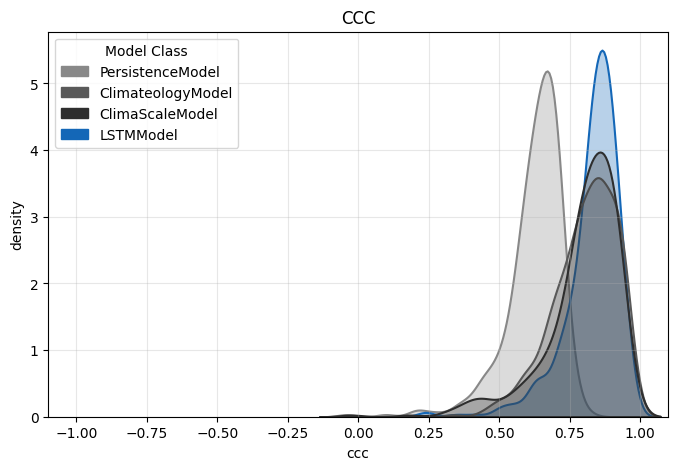

In [ ]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'kde', vmin = -1.1, vmax=1.1, log=False).show()

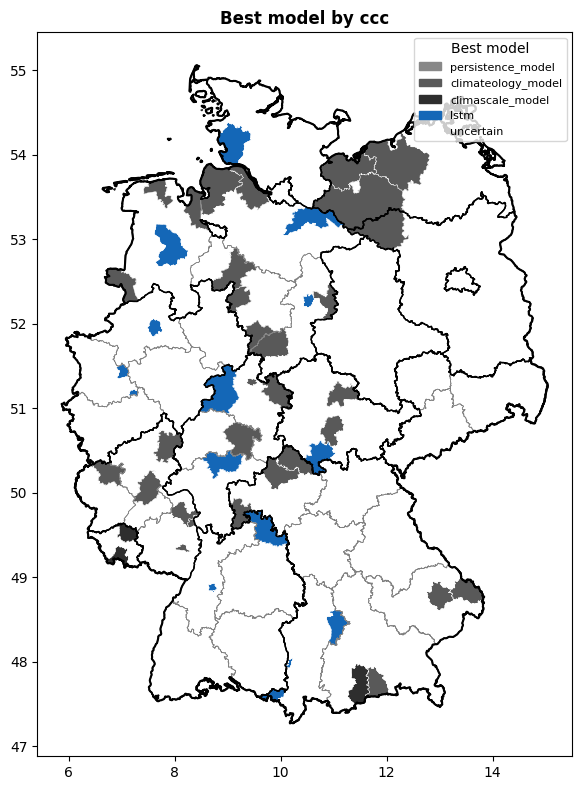

In [ ]:
# model_evaluation.plotter.plot_single_metric('ccc',0, plot_type='map', log = False, reverse_scale=True, vmin = 0, vmax=  1)
model_evaluation.plotter.plot_single_metric('ccc',0, plot_type='best_map', margin_sd=1).show()

<Axes: >

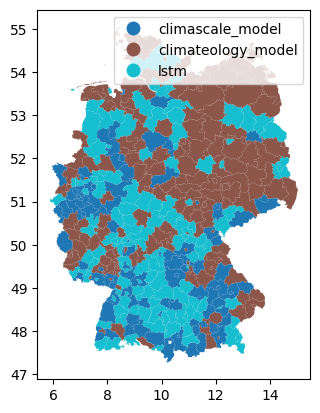

In [ ]:
metrics = ['ccc']


metrics_df = model_evaluation.data_compilation.get_data(0,'test')['metrics']

model_cols = list(metrics_df['model'].unique())

for metric in metrics:
    df_long = metrics_df[['nuts_node','model',metric]]
    df_wide = df_long.pivot_table(index = 'nuts_node', columns = 'model', values = metric).reset_index(drop = False).reset_index(drop = True)
    df_wide['best'] = df_wide[model_cols].idxmax(axis=1)

import seaborn as sns 

import pandas as pd
shp = data_orch._data_context.shapedata_node

shp = pd.merge(shp, df_wide, on = 'nuts_node')

shp.plot(column = 'best', legend = True)